In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import re
import string

import nltk

In [83]:
from sklearn.metrics import confusion_matrix

In [2]:
train_df = pd.read_csv("./data/train.csv")
test_df = pd.read_csv("./data/test.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (120000, 3)
Testing data shape: (7600, 3)


In [3]:
test_df.head()
train_df.head()

,Class Index,Title,Description
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli..."
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco..."


In [4]:
print("Training columns:")
print(train_df.columns)

print("\nTesting columns:")
print(test_df.columns)

Training columns:
Index(['Class Index', 'Title', 'Description'], dtype='object')

Testing columns:
Index(['Class Index', 'Title', 'Description'], dtype='object')


In [5]:
train_df.info()
test_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 120000 entries, 0 to 119999
Data columns (total 3 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   Class Index  120000 non-null  int64 
 1   Title        120000 non-null  object
 2   Description  120000 non-null  object
dtypes: int64(1), object(2)
memory usage: 2.7+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7600 entries, 0 to 7599
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Class Index  7600 non-null   int64 
 1   Title        7600 non-null   object
 2   Description  7600 non-null   object
dtypes: int64(1), object(2)
memory usage: 178.3+ KB


In [6]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
Class Index    0
Title          0
Description    0
dtype: int64

Missing values in testing data:
Class Index    0
Title          0
Description    0
dtype: int64


In [7]:
print("Missing values in training data:")
print(train_df.isnull().sum())

print("\nMissing values in testing data:")
print(test_df.isnull().sum())

Missing values in training data:
Class Index    0
Title          0
Description    0
dtype: int64

Missing values in testing data:
Class Index    0
Title          0
Description    0
dtype: int64


In [8]:
print(train_df["Class Index"].value_counts().sort_index())

Class Index
1    30000
2    30000
3    30000
4    30000
Name: count, dtype: int64


In [9]:
print(test_df["Class Index"].value_counts().sort_index())

Class Index
1    1900
2    1900
3    1900
4    1900
Name: count, dtype: int64


In [10]:
class_names = {
    1: "World",
    2: "Sports",
    3: "Business",
    4: "Sci/Tech"
}

In [11]:
train_df["Category"] = train_df["Class Index"].map(class_names)
test_df["Category"] = test_df["Class Index"].map(class_names)

In [12]:
train_df[["Class Index" , "Category"]].head()

,Class Index,Category
0,3,Business
1,3,Business
2,3,Business
3,3,Business
4,3,Business


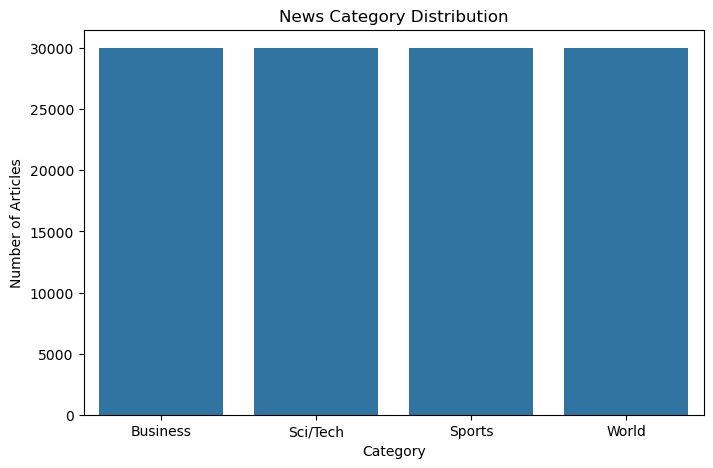

In [13]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=train_df,
    x="Category"
)

plt.title("News Category Distribution")
plt.xlabel("Category")
plt.ylabel("Number of Articles")
plt.show()

In [14]:
train_df["Text"] = (
    train_df["Title"].fillna("") + " " +
    train_df["Description"].fillna("")
)

test_df["Text"] = (
    test_df["Title"].fillna("") + " " +
    test_df["Description"].fillna("")
)

In [15]:
print(train_df["Text"].iloc[0])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [16]:
print(train_df["Text"].iloc[0])

Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.


In [17]:
nltk.download("punkt")
nltk.download("stopwords")
nltk.download("wordnet")
nltk.download("omw-1.4")

[nltk_data] Downloading package punkt to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package wordnet to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to C:\Users\Asad
[nltk_data]     Computers\AppData\Roaming\nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!


True

In [18]:
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

stop_words = set(stopwords.words("english"))
lemmatizer = WordNetLemmatizer()

In [19]:
def preprocess_text(text):
    
    # Convert text to lowercase
    text = text.lower()
    
    # Replace backslashes with spaces
    text = re.sub(r"\\", " ", text)
    
    # Remove punctuation and numbers
    text = re.sub(r"[^a-zA-Z\s]", " ", text)
    
    # Remove extra whitespace
    text = re.sub(r"\s+", " ", text).strip()
    
    # Tokenization
    tokens = word_tokenize(text)
    
    # Remove stopwords
    tokens = [
        word for word in tokens
        if word not in stop_words
    ]
    
    # Lemmatization
    tokens = [
        lemmatizer.lemmatize(word)
        for word in tokens
    ]
    
    # Convert tokens back to text
    return " ".join(tokens)

In [20]:
for i in range(3):
    print(f"\nARTICLE {i+1}")
    print("Original:")
    print(train_df["Text"].iloc[i][:300])
    
    print("\nProcessed:")
    print(preprocess_text(train_df["Text"].iloc[i])[:300])
    
    print("-" * 80)


ARTICLE 1
Original:
Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\band of ultra-cynics, are seeing green again.

Processed:
wall st bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green
--------------------------------------------------------------------------------

ARTICLE 2
Original:
Carlyle Looks Toward Commercial Aerospace (Reuters) Reuters - Private investment firm Carlyle Group,\which has a reputation for making well-timed and occasionally\controversial plays in the defense industry, has quietly placed\its bets on another part of the market.

Processed:
carlyle look toward commercial aerospace reuters reuters private investment firm carlyle group reputation making well timed occasionally controversial play defense industry quietly placed bet another part market
--------------------------------------------------------------------------------

ARTICLE 3
Original:
Oil and Economy C

In [21]:
train_df.shape
test_df.shape
train_df.head()

,Class Index,Title,Description,Category,Text
0,3,Wall St. Bears Claw Back Into the Black (Reuters),"Reuters - Short-sellers, Wall Street's dwindli...",Business,Wall St. Bears Claw Back Into the Black (Reute...
1,3,Carlyle Looks Toward Commercial Aerospace (Reu...,Reuters - Private investment firm Carlyle Grou...,Business,Carlyle Looks Toward Commercial Aerospace (Reu...
2,3,Oil and Economy Cloud Stocks' Outlook (Reuters),Reuters - Soaring crude prices plus worries\ab...,Business,Oil and Economy Cloud Stocks' Outlook (Reuters...
3,3,Iraq Halts Oil Exports from Main Southern Pipe...,Reuters - Authorities have halted oil export\f...,Business,Iraq Halts Oil Exports from Main Southern Pipe...
4,3,"Oil prices soar to all-time record, posing new...","AFP - Tearaway world oil prices, toppling reco...",Business,"Oil prices soar to all-time record, posing new..."


In [22]:
train_df["Clean_Text"] = train_df["Text"].apply(preprocess_text)
test_df["Clean_Text"] = test_df["Text"].apply(preprocess_text)

In [23]:
print(train_df[["Text", "Clean_Text"]].head())

                                                Text  \
0  Wall St. Bears Claw Back Into the Black (Reute...   
1  Carlyle Looks Toward Commercial Aerospace (Reu...   
2  Oil and Economy Cloud Stocks' Outlook (Reuters...   
3  Iraq Halts Oil Exports from Main Southern Pipe...   
4  Oil prices soar to all-time record, posing new...   

                                          Clean_Text  
0  wall st bear claw back black reuters reuters s...  
1  carlyle look toward commercial aerospace reute...  
2  oil economy cloud stock outlook reuters reuter...  
3  iraq halt oil export main southern pipeline re...  
4  oil price soar time record posing new menace u...  


In [24]:
print("Training articles:", len(train_df))
print("Testing articles:", len(test_df))

Training articles: 120000
Testing articles: 7600


In [25]:
print("Empty training texts:",
      (train_df["Clean_Text"].str.strip() == "").sum())

print("Empty testing texts:",
      (test_df["Clean_Text"].str.strip() == "").sum())

Empty training texts: 0
Empty testing texts: 0


In [26]:
print(train_df["Clean_Text"].iloc[0])

wall st bear claw back black reuters reuters short seller wall street dwindling band ultra cynic seeing green


In [27]:
X_train_text = train_df["Clean_Text"]
X_test_text = test_df["Clean_Text"]

y_train = train_df["Class Index"]
y_test = test_df["Class Index"]

In [28]:
print("X_train:", X_train_text.shape)
print("X_test:", X_test_text.shape)

print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (120000,)
X_test: (7600,)
y_train: (120000,)
y_test: (7600,)


In [29]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [30]:
tfidf = TfidfVectorizer(
    max_features=50000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95
)

In [31]:
X_train = tfidf.fit_transform(X_train_text)

In [32]:
X_test = tfidf.transform(X_test_text)

In [33]:
print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (120000, 50000)
X_test shape: (7600, 50000)


In [34]:
print(type(X_train))

<class 'scipy.sparse._csr.csr_matrix'>


In [35]:
features = tfidf.get_feature_names_out()

print("Number of features:", len(features))
print("\nFirst 50 features:")
print(features[:50])

Number of features: 50000

First 50 features:
['aa' 'aa billion' 'aaa' 'aapl' 'aapl lt' 'aapl qtype' 'aaron'
 'aaron peirsol' 'aaron rodgers' 'ab' 'ababa' 'abandon'
 'abandon microsoft' 'abandon nuclear' 'abandoned' 'abandoning' 'abb'
 'abbas' 'abbey' 'abbey bid' 'abbey national' 'abbott' 'abbott laboratory'
 'abby' 'abby wambach' 'abc' 'abc news' 'abdicate' 'abdicated'
 'abdication' 'abducted' 'abducted baghdad' 'abducted iraq' 'abducting'
 'abduction' 'abductor' 'abdul' 'abdul kalam' 'abdullah' 'abdullah ahmad'
 'abdullah ii' 'abdur' 'abercrombie' 'aberdeen' 'abide' 'abidjan'
 'abidjan ivory' 'abidjan reuters' 'ability' 'ability run']


In [36]:
y_train = y_train - 1
y_test = y_test - 1

In [37]:
print("Training labels:", np.unique(y_train))
print("Testing labels:", np.unique(y_test))

Training labels: [0 1 2 3]
Testing labels: [0 1 2 3]


In [38]:
from sklearn.linear_model import LogisticRegression

In [39]:
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

In [40]:
logistic_model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [41]:
y_pred_lr = logistic_model.predict(X_test)

In [42]:
print("Actual labels:   ", y_test[:10])
print("Predicted labels:", y_pred_lr[:10])

Actual labels:    0    2
1    3
2    3
3    3
4    3
5    3
6    3
7    3
8    3
9    3
Name: Class Index, dtype: int64
Predicted labels: [2 3 3 3 3 3 3 3 3 3]


In [43]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report
)

In [44]:
accuracy_lr = accuracy_score(y_test, y_pred_lr)

precision_lr = precision_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

recall_lr = recall_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

f1_lr = f1_score(
    y_test,
    y_pred_lr,
    average="weighted"
)

In [45]:
print("Logistic Regression Results")
print("-" * 35)
print(f"Accuracy : {accuracy_lr:.4f}")
print(f"Precision: {precision_lr:.4f}")
print(f"Recall   : {recall_lr:.4f}")
print(f"F1-Score : {f1_lr:.4f}")

Logistic Regression Results
-----------------------------------
Accuracy : 0.9197
Precision: 0.9195
Recall   : 0.9197
F1-Score : 0.9196


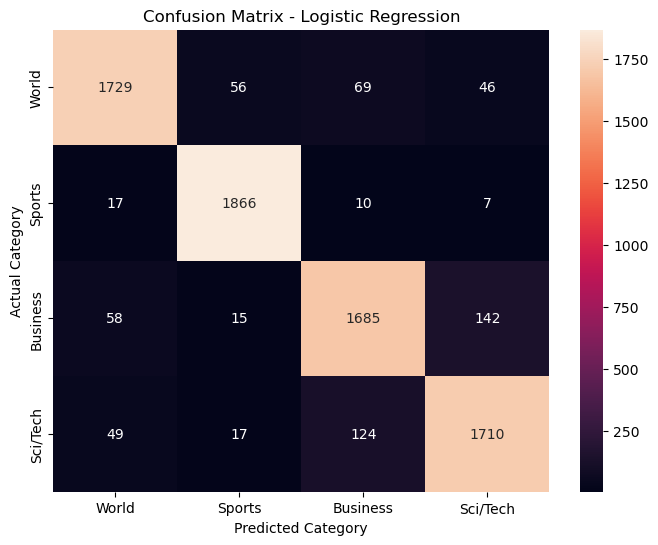

In [86]:
class_names = [
    "World",
    "Sports",
    "Business",
    "Sci/Tech"
]

cm = confusion_matrix(y_test, y_pred_lr)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Logistic Regression")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [50]:
from sklearn.naive_bayes import MultinomialNB

In [51]:
nb_model = MultinomialNB()

In [52]:
nb_model.fit(X_train, y_train)

,alpha,1.0
,force_alpha,True
,fit_prior,True
,class_prior,None


In [66]:
y_pred_nb = nb_model.predict(X_test)

In [67]:
accuracy_nb = accuracy_score(y_test, y_pred_nb)

precision_nb = precision_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

recall_nb = recall_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

f1_nb = f1_score(
    y_test,
    y_pred_nb,
    average="weighted"
)

print("Multinomial Naive Bayes Results")
print("-" * 40)
print(f"Accuracy : {accuracy_nb:.4f}")
print(f"Precision: {precision_nb:.4f}")
print(f"Recall   : {recall_nb:.4f}")
print(f"F1-Score : {f1_nb:.4f}")

Multinomial Naive Bayes Results
----------------------------------------
Accuracy : 0.9037
Precision: 0.9033
Recall   : 0.9037
F1-Score : 0.9032


In [68]:
print(
    classification_report(
        y_test,
        y_pred_nb,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       World       0.92      0.89      0.91      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.88      0.85      0.86      1900
    Sci/Tech       0.87      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



In [69]:
from sklearn.svm import LinearSVC

In [70]:
svm_model = LinearSVC(
    random_state=42
)

In [71]:
svm_model.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,1.0
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [72]:
y_pred_svm = svm_model.predict(X_test)

In [73]:
accuracy_svm = accuracy_score(y_test, y_pred_svm)

precision_svm = precision_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

recall_svm = recall_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

f1_svm = f1_score(
    y_test,
    y_pred_svm,
    average="weighted"
)

print("Linear SVM Results")
print("-" * 35)
print(f"Accuracy : {accuracy_svm:.4f}")
print(f"Precision: {precision_svm:.4f}")
print(f"Recall   : {recall_svm:.4f}")
print(f"F1-Score : {f1_svm:.4f}")

Linear SVM Results
-----------------------------------
Accuracy : 0.9224
Precision: 0.9222
Recall   : 0.9224
F1-Score : 0.9222


In [74]:
print(
    classification_report(
        y_test,
        y_pred_svm,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       World       0.93      0.92      0.92      1900
      Sports       0.96      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600



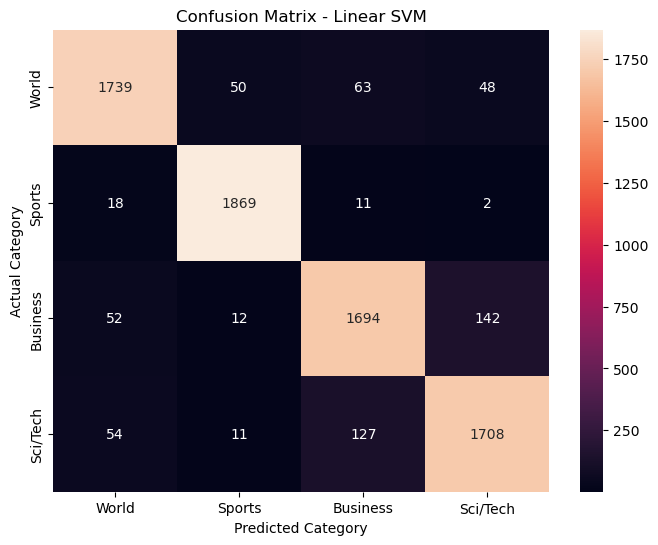

In [85]:
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_svm,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Linear SVM")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [76]:
from sklearn.ensemble import RandomForestClassifier

In [77]:
rf_model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

In [78]:
rf_model.fit(X_train, y_train)

,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [79]:
y_pred_rf = rf_model.predict(X_test)

In [80]:
accuracy_rf = accuracy_score(y_test, y_pred_rf)

precision_rf = precision_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

recall_rf = recall_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

f1_rf = f1_score(
    y_test,
    y_pred_rf,
    average="weighted"
)

print("Random Forest Results")
print("-" * 35)
print(f"Accuracy : {accuracy_rf:.4f}")
print(f"Precision: {precision_rf:.4f}")
print(f"Recall   : {recall_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")

Random Forest Results
-----------------------------------
Accuracy : 0.9009
Precision: 0.9006
Recall   : 0.9009
F1-Score : 0.9006


In [81]:
print(
    classification_report(
        y_test,
        y_pred_rf,
        target_names=class_names
    )
)

              precision    recall  f1-score   support

       World       0.92      0.90      0.91      1900
      Sports       0.93      0.97      0.95      1900
    Business       0.88      0.86      0.87      1900
    Sci/Tech       0.88      0.88      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600



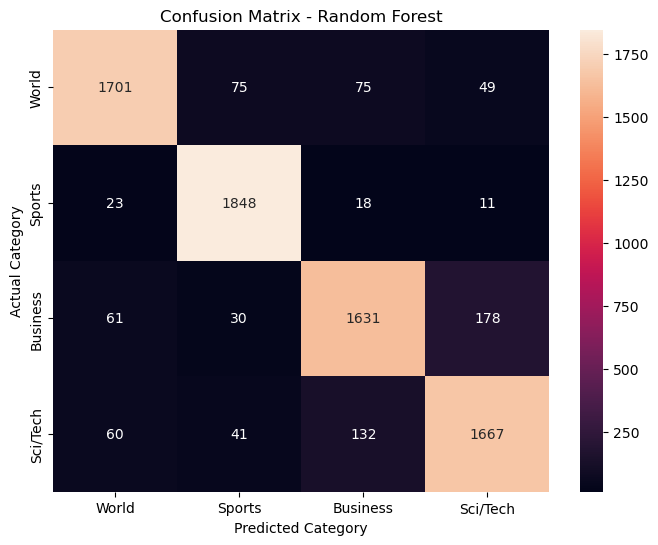

In [84]:
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_rf,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Random Forest")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [87]:
results = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Multinomial Naive Bayes",
        "Linear SVM",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy_lr,
        accuracy_nb,
        accuracy_svm,
        accuracy_rf
    ],
    "Precision": [
        precision_lr,
        precision_nb,
        precision_svm,
        precision_rf
    ],
    "Recall": [
        recall_lr,
        recall_nb,
        recall_svm,
        recall_rf
    ],
    "F1-Score": [
        f1_lr,
        f1_nb,
        f1_svm,
        f1_rf
    ]
})

results

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,0.919737,0.919541,0.919737,0.919552
1,Multinomial Naive Bayes,0.903684,0.903281,0.903684,0.903248
2,Linear SVM,0.922368,0.922182,0.922368,0.922224
3,Random Forest,0.900921,0.900642,0.900921,0.900564


In [88]:
comparison = results.copy()

for column in ["Accuracy", "Precision", "Recall", "F1-Score"]:
    comparison[column] = (
        comparison[column] * 100
    ).round(2)

comparison

,Model,Accuracy,Precision,Recall,F1-Score
0,Logistic Regression,91.97,91.95,91.97,91.96
1,Multinomial Naive Bayes,90.37,90.33,90.37,90.32
2,Linear SVM,92.24,92.22,92.24,92.22
3,Random Forest,90.09,90.06,90.09,90.06


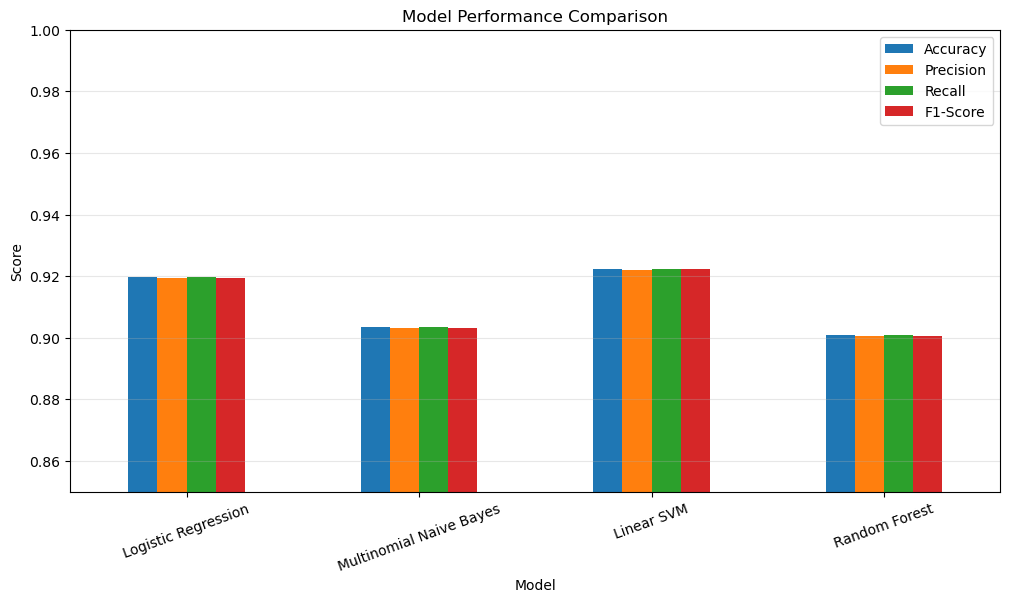

In [89]:
comparison_plot = results.set_index("Model")[
    ["Accuracy", "Precision", "Recall", "F1-Score"]
]

comparison_plot.plot(
    kind="bar",
    figsize=(12, 6)
)

plt.title("Model Performance Comparison")
plt.xlabel("Model")
plt.ylabel("Score")
plt.ylim(0.85, 1.0)
plt.xticks(rotation=20)
plt.legend()
plt.grid(axis="y", alpha=0.3)
plt.show()

In [90]:
print("LOGISTIC REGRESSION")
print(classification_report(
    y_test,
    y_pred_lr,
    target_names=class_names
))

print("\nNAIVE BAYES")
print(classification_report(
    y_test,
    y_pred_nb,
    target_names=class_names
))

print("\nLINEAR SVM")
print(classification_report(
    y_test,
    y_pred_svm,
    target_names=class_names
))

print("\nRANDOM FOREST")
print(classification_report(
    y_test,
    y_pred_rf,
    target_names=class_names
))

LOGISTIC REGRESSION
              precision    recall  f1-score   support

       World       0.93      0.91      0.92      1900
      Sports       0.95      0.98      0.97      1900
    Business       0.89      0.89      0.89      1900
    Sci/Tech       0.90      0.90      0.90      1900

    accuracy                           0.92      7600
   macro avg       0.92      0.92      0.92      7600
weighted avg       0.92      0.92      0.92      7600


NAIVE BAYES
              precision    recall  f1-score   support

       World       0.92      0.89      0.91      1900
      Sports       0.94      0.98      0.96      1900
    Business       0.88      0.85      0.86      1900
    Sci/Tech       0.87      0.89      0.88      1900

    accuracy                           0.90      7600
   macro avg       0.90      0.90      0.90      7600
weighted avg       0.90      0.90      0.90      7600


LINEAR SVM
              precision    recall  f1-score   support

       World       0.93      0

In [91]:
from sklearn.model_selection import train_test_split

X_train_tune, X_val, y_train_tune, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.20,
    random_state=42,
    stratify=y_train
)

print("Training samples:", X_train_tune.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 96000
Validation samples: 24000


In [92]:
C_values = [0.1, 0.5, 1, 2, 5]

svm_tuning_results = []

for c in C_values:
    
    print(f"Training Linear SVM with C={c}...")
    
    model = LinearSVC(
        C=c,
        random_state=42
    )
    
    model.fit(X_train_tune, y_train_tune)
    
    val_predictions = model.predict(X_val)
    
    accuracy = accuracy_score(
        y_val,
        val_predictions
    )
    
    f1 = f1_score(
        y_val,
        val_predictions,
        average="weighted"
    )
    
    svm_tuning_results.append({
        "C": c,
        "Accuracy": accuracy,
        "F1-Score": f1
    })

Training Linear SVM with C=0.1...
Training Linear SVM with C=0.5...
Training Linear SVM with C=1...
Training Linear SVM with C=2...
Training Linear SVM with C=5...


In [93]:
svm_tuning_df = pd.DataFrame(svm_tuning_results)

svm_tuning_df

,C,Accuracy,F1-Score
0,0.1,0.924583,0.924364
1,0.5,0.926500,0.926327
2,1.0,0.923958,0.923810
3,2.0,0.919750,0.919605
4,5.0,0.911875,0.911764


In [94]:
best_c = svm_tuning_df.loc[
    svm_tuning_df["F1-Score"].idxmax(),
    "C"
]

print("Best C:", best_c)

Best C: 0.5


In [96]:
svm_tuning_df.loc[
    svm_tuning_df["F1-Score"].idxmax()
]

C           0.500000
Accuracy    0.926500
F1-Score    0.926327
Name: 1, dtype: float64

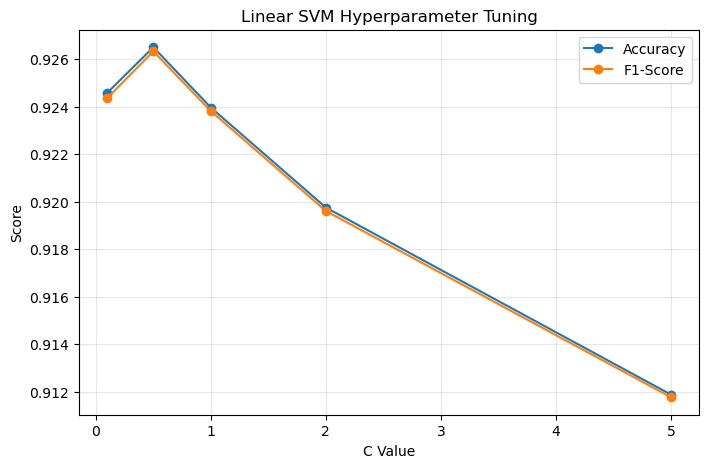

In [97]:
plt.figure(figsize=(8, 5))

plt.plot(
    svm_tuning_df["C"],
    svm_tuning_df["Accuracy"],
    marker="o",
    label="Accuracy"
)

plt.plot(
    svm_tuning_df["C"],
    svm_tuning_df["F1-Score"],
    marker="o",
    label="F1-Score"
)

plt.xlabel("C Value")
plt.ylabel("Score")
plt.title("Linear SVM Hyperparameter Tuning")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [98]:
final_svm = LinearSVC(
    C=best_c,
    random_state=42
)

final_svm.fit(X_train, y_train)

,penalty,'l2'
,loss,'squared_hinge'
,dual,'auto'
,tol,0.0001
,C,np.float64(0.5)
,multi_class,'ovr'
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,verbose,0
,random_state,42


In [99]:
y_pred_final = final_svm.predict(X_test)

In [100]:
final_accuracy = accuracy_score(
    y_test,
    y_pred_final
)

final_precision = precision_score(
    y_test,
    y_pred_final,
    average="weighted"
)

final_recall = recall_score(
    y_test,
    y_pred_final,
    average="weighted"
)

final_f1 = f1_score(
    y_test,
    y_pred_final,
    average="weighted"
)

print("Final Tuned Linear SVM")
print("-" * 40)
print(f"Accuracy : {final_accuracy:.4f}")
print(f"Precision: {final_precision:.4f}")
print(f"Recall   : {final_recall:.4f}")
print(f"F1-Score : {final_f1:.4f}")

Final Tuned Linear SVM
----------------------------------------
Accuracy : 0.9236
Precision: 0.9234
Recall   : 0.9236
F1-Score : 0.9234


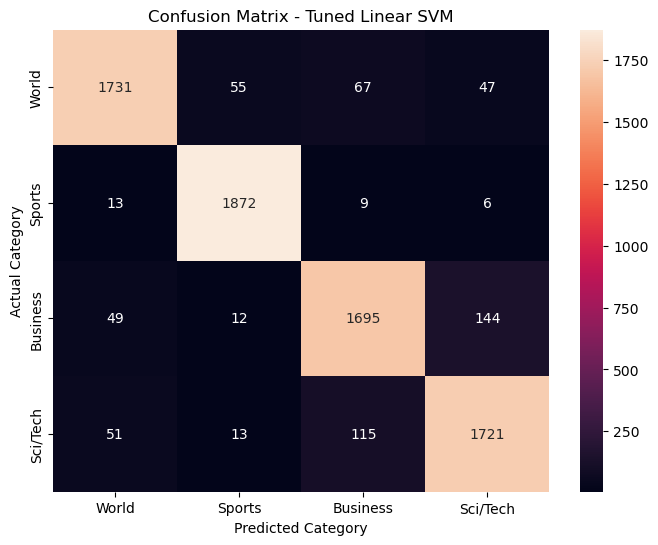

In [101]:
cm_final = confusion_matrix(
    y_test,
    y_pred_final
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm_final,
    annot=True,
    fmt="d",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Tuned Linear SVM")
plt.xlabel("Predicted Category")
plt.ylabel("Actual Category")
plt.show()

In [102]:
svm_comparison = pd.DataFrame({
    "Version": [
        "Original Linear SVM",
        "Tuned Linear SVM"
    ],
    "Accuracy": [
        accuracy_svm,
        final_accuracy
    ],
    "Precision": [
        precision_svm,
        final_precision
    ],
    "Recall": [
        recall_svm,
        final_recall
    ],
    "F1-Score": [
        f1_svm,
        final_f1
    ]
})

svm_comparison

,Version,Accuracy,Precision,Recall,F1-Score
0,Original Linear SVM,0.922368,0.922182,0.922368,0.922224
1,Tuned Linear SVM,0.923553,0.923438,0.923553,0.923391


In [107]:
def predict_news_category(news_text):
    
    cleaned_text = preprocess_text(news_text)
    
    text_vector = tfidf.transform([cleaned_text])
    
    prediction = final_svm.predict(text_vector)[0]
    
    category = class_names[prediction]
    
    print("Predicted Category:", category)
    
    return category

In [110]:
news = """
Apple announced a new artificial intelligence chip
for its upcoming devices.
"""

predict_news_category(news)

Predicted Category: Sci/Tech


'Sci/Tech'

In [111]:
import joblib

In [112]:
joblib.dump(final_svm, "news_category_svm.pkl")

['news_category_svm.pkl']

In [113]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']

In [114]:
joblib.dump(class_names, "class_names.pkl")

['class_names.pkl']